In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn import preprocessing

In [3]:
df= pd.read_csv('USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [6]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


#### Data Prep

1. Dropping the columns which are not needed
2. Visualizing the feature dependency
3. Making Sure that there are no null or duplicate values

In [8]:
#Dropping Address
df.drop('Address', axis=1, inplace=True)

C:\Users\HI\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


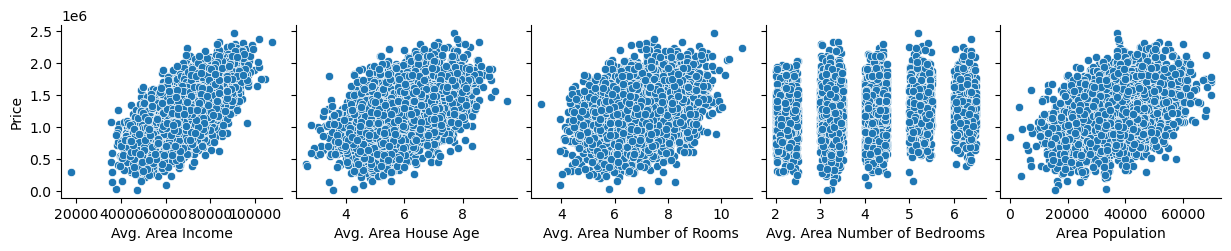

In [10]:
#Exploring correlation of features with price using scatterplot
sns.pairplot(data=df, x_vars =['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms','Avg. Area Number of Bedrooms', 'Area Population'], y_vars= 'Price')
plt.show()

<Axes: >

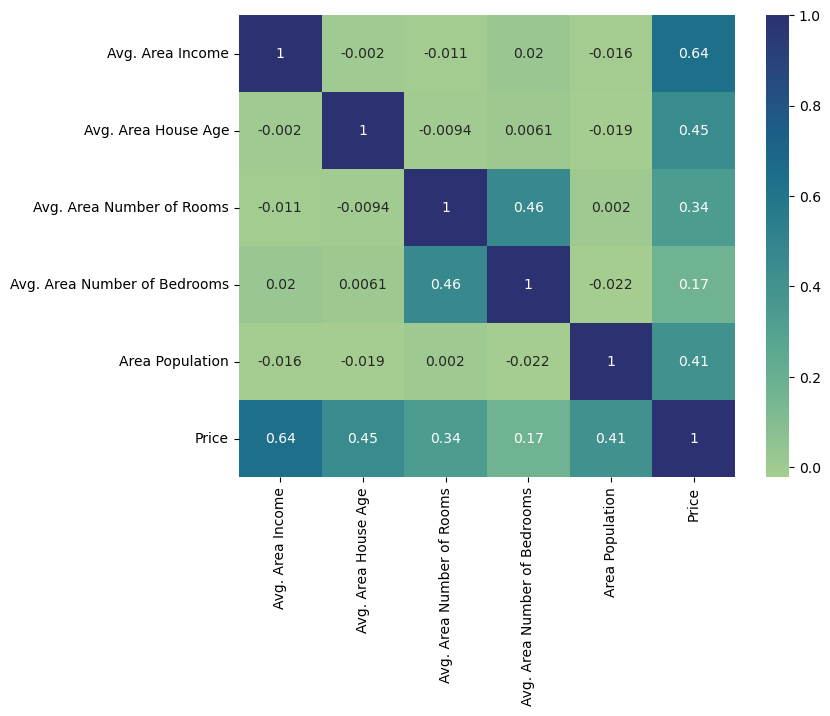

In [13]:
#Exploring correlation of features with price using heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='crest')

In [15]:
#Exploring correlation of features with price statistically
df.corr().Price.sort_values(ascending=True)

Avg. Area Number of Bedrooms    0.171071
Avg. Area Number of Rooms       0.335664
Area Population                 0.408556
Avg. Area House Age             0.452543
Avg. Area Income                0.639734
Price                           1.000000
Name: Price, dtype: float64

Conclusion - Price is most correlated on Area income and least correlated on Number of Bedrooms

___________________________________________________

Scaling the features

In [19]:
scaler = preprocessing.StandardScaler()

X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population']]

X_scaled = scaler.fit_transform(X) #X_scaled is an array right now
X = pd.DataFrame(X_scaled, columns=X.columns) # Converting X to a dataframe

y= df['Price']  # Now we have our X and y for split

In [20]:
X.head() #Scaled the features

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,1.028660,-0.296927,0.021274,0.088062,-1.317599
1,1.000808,0.025902,-0.255506,-0.722301,0.403999
2,-0.684629,-0.112303,1.516243,0.930840,0.072410
3,-0.491499,1.221572,-1.393077,-0.584540,-0.186734
4,-0.807073,-0.944834,0.846742,0.201513,-0.988387


In [21]:
y.head()#Scaled the feature

0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64

Train-test split

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.7, test_size=0.3, random_state=2)
# random_state is needed so that dame group are assigned to train and test everytime we run the code

In [26]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3500, 5)
(1500, 5)
(3500,)
(1500,)


Training on model

In [30]:
from sklearn.linear_model import LinearRegression
lrmodel = LinearRegression()
lrmodel.fit(X_train, y_train)

LinearRegression()

In [31]:
# taking a look at intercept_, intercept is the value of model when all the features are 0
print(lrmodel.intercept_)

1231006.3190642651


In [33]:
# take a look at coefficients. coefficients of each feature tells their weightage, importance
coeff_df= pd.DataFrame({
    'fetaures': X.columns,
    'Coefficient' : lrmodel.coef_
})
print(coeff_df)

                       fetaures    Coefficient
0              Avg. Area Income  229275.224032
1           Avg. Area House Age  163592.487140
2     Avg. Area Number of Rooms  120113.253351
3  Avg. Area Number of Bedrooms    3015.847572
4               Area Population  150556.340296


In [36]:
# Now making the prediction
y_pred = lrmodel.predict(X_test)

Evaluating the model

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
r2= r2_score(y_test, y_pred)
print(r2)

mae= mean_absolute_error(y_test, y_pred)
print(mae)

mse= mean_squared_error(y_test, y_pred)
print(mse)

0.9199287959786013
79912.70946052398
9831074697.74044


### Conclusion

##### The model’s performance was evaluated using R², MAE, and MSE.

R² = 0.92 → The model captures 92% of the data pattern, which is quite good.

MAE = 79,912 → On average, predicted prices differ from actual prices by ~80k, which is acceptable.

MSE = 9,831,074,697 → Average squared error is high due to squaring, but considering R² and MAE, the model fit is still very good.

___________________________

We can still try to better the model by getting rid of the feature(s) which are not highly or moderately correlated to features

In [42]:
# Again looking at the correlation

df.corr().Price.sort_values(ascending=True)

Avg. Area Number of Bedrooms    0.171071
Avg. Area Number of Rooms       0.335664
Area Population                 0.408556
Avg. Area House Age             0.452543
Avg. Area Income                0.639734
Price                           1.000000
Name: Price, dtype: float64

We can conclude that Avg. Area Number of Bedrooms is least correlated so we can drop it off from our features

In [43]:
X.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population'],
      dtype='object')

In [47]:
X.drop('Avg. Area Number of Bedrooms', axis = 1, inplace=True)

KeyError: "['Avg. Area Number of Bedrooms'] not found in axis"

In [48]:
X.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Area Population'],
      dtype='object')

In [49]:
# Now that we have a new X, lets do the split again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=2)

In [50]:
# Now fit it to the LR model
from sklearn.linear_model import LinearRegression

lrmodel2 = LinearRegression()
lrmodel2.fit(X_train, y_train)

LinearRegression()

In [51]:
y_pred2 = lrmodel2.predict(X_test)

In [52]:
# Now again evaluating the new 

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

r2 = r2_score(y_test, y_pred)
print(r2)

mae = mean_absolute_error(y_test, y_pred)
print(mae)

mse = mean_squared_error(y_test, y_pred)
print(mse)

0.9199287959786013
79912.70946052398
9831074697.74044


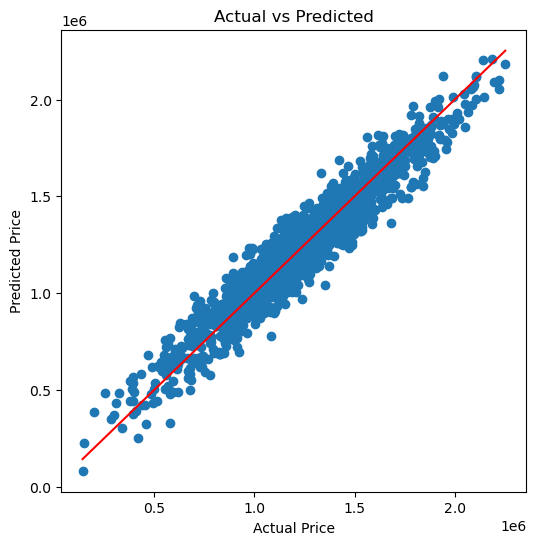

In [56]:
# Visualizing our model

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r')
plt.show()


## 🔚 Model Evaluation Conclusion

We trained a Linear Regression model to predict house prices and evaluated it before and after removing a low-correlation feature.

#### **📌 Results Comparison**

| Metric       | Before Feature Removal | After Feature Removal | Interpretation                                             |
| ------------ | ---------------------- | --------------------- | ---------------------------------------------------------- |
| **R² Score** | 0.9199287              | 0.9199910             | Slight improvement in how well the model explains variance |
| **MAE**      | 79,912.70              | 79,830.14             | Average prediction error decreased                         |
| **MSE**      | 9,831,074,697          | 9,823,431,323         | Overall error reduced                                      |

#### **📎 Conclusion**

Removing the weakly correlated feature led to a performance improvement. Shows that cleaning and selecting relevant features can positively affect the model's performance.

